# Week 4: Dimensionality Reduction Practice with "hw5_treasury yield curve data.csv" Dataset

## Overview
This practice includes the following steps:

0. **Introduction**
1. **Data Loading and Preparation**
2. **Exploratory Data Analysis (EDA)**
3. **Principal Component Analysis (PCA)**
4. **Model Fitting**
   - 4.1 Linear Regression
   - 4.2 Support Vector Regression (SVR)
5. **Model Comparison**

# 0. Introduction


This practice applies dimensionality reduction techniques to the Treasury Yield Curve dataset.
We first perform exploratory data analysis, then use PCA to reduce the 30 original attributes to three principal components.
We compare Linear Regression and SVR on both the original and PCA-transformed datasets using R^2, RMSE, and training time.

# 1. Data Loading and Preparation

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# read the housing dataset
path = '/content/drive/MyDrive/UIUC/IE 498 - Machine Learning in Finance/week5/hw5_treasury yield curve data.csv'
data = pd.read_csv(path, index_col=0, parse_dates=True, na_values=['NA', 'Nan', 'N/A', 'na', 'n/a', 'null', 'NULL', 'None', 'none', ''])

print(f"{data.columns}")
data.head()

Index(['SVENF01', 'SVENF02', 'SVENF03', 'SVENF04', 'SVENF05', 'SVENF06',
       'SVENF07', 'SVENF08', 'SVENF09', 'SVENF10', 'SVENF11', 'SVENF12',
       'SVENF13', 'SVENF14', 'SVENF15', 'SVENF16', 'SVENF17', 'SVENF18',
       'SVENF19', 'SVENF20', 'SVENF21', 'SVENF22', 'SVENF23', 'SVENF24',
       'SVENF25', 'SVENF26', 'SVENF27', 'SVENF28', 'SVENF29', 'SVENF30',
       'Adj_Close'],
      dtype='object')


,SVENF01,SVENF02,SVENF03,SVENF04,SVENF05,SVENF06,SVENF07,SVENF08,SVENF09,SVENF10,...,SVENF22,SVENF23,SVENF24,SVENF25,SVENF26,SVENF27,SVENF28,SVENF29,SVENF30,Adj_Close
Date,,,,,,,,,,,,,,,,,,,,,
2019-05-17,2.1224,2.0266,2.1023,2.2377,2.3790,2.5042,2.6069,2.6885,2.7530,2.8054,...,3.3355,3.3876,3.4400,3.4925,3.5446,3.5962,3.6471,3.6970,3.7458,10.130177
2019-05-16,2.1239,2.0317,2.1096,2.2468,2.3901,2.5171,2.6217,2.7049,2.7710,2.8247,...,3.3574,3.4091,3.4610,3.5130,3.5646,3.6156,3.6660,3.7153,3.7636,10.130177
2019-05-15,2.0874,1.9956,2.0844,2.2289,2.3736,2.4980,2.5984,2.6779,2.7418,2.7951,...,3.3589,3.4086,3.4575,3.5055,3.5524,3.5980,3.6421,3.6847,3.7257,10.150118
2019-05-14,2.1319,2.0559,2.1451,2.2856,2.4257,2.5461,2.6428,2.7188,2.7791,2.8289,...,3.3940,3.4485,3.5029,3.5568,3.6099,3.6622,3.7132,3.7630,3.8113,10.130177
2019-05-13,2.1051,2.0234,2.1180,2.2632,2.4051,2.5248,2.6198,2.6940,2.7532,2.8029,...,3.3712,3.4227,3.4735,3.5234,3.5722,3.6196,3.6655,3.7098,3.7525,10.130177


# 2. Exploratory Data Analysis

### Basic Information

In [9]:
# Basic information

# 1. Number of rows and columns
print("1. Shape of data:")
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])

# 2. Number of categorical variables and number of unique values for each
categorical_cols = data.select_dtypes(include=['object', 'category', 'string']).columns
categorical_summary = pd.DataFrame({'number of unique values': data[categorical_cols].nunique()})
print("\n2. Categorical variables:")
display(categorical_summary)

# 3. Missing values
print("\n3. Missing values:")
missing_summary = pd.DataFrame({'Missing Values': data.isnull().sum(), 'Missing Percentage': data.isnull().mean()*100})
display(missing_summary[missing_summary['Missing Values'] > 0])  # print if nan > 0

# 4. Summary statistics for attributes and labels (numerical variables)
numerical_cols = data.select_dtypes(include='number').columns
print("\n4. Summary statistics for numerical attributes:")
display(data[numerical_cols].describe())

1. Shape of data:
Number of rows: 8071
Number of columns: 31

2. Categorical variables:


,number of unique values



3. Missing values:


,Missing Values,Missing Percentage



4. Summary statistics for numerical attributes:


,SVENF01,SVENF02,SVENF03,SVENF04,SVENF05,SVENF06,SVENF07,SVENF08,SVENF09,SVENF10,...,SVENF22,SVENF23,SVENF24,SVENF25,SVENF26,SVENF27,SVENF28,SVENF29,SVENF30,Adj_Close
count,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,...,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000,8071.000000
mean,3.785311,4.258972,4.669363,5.022430,5.318493,5.559644,5.750071,5.895135,6.000596,6.072112,...,5.689046,5.621666,5.554136,5.486943,5.420479,5.355063,5.290948,5.228333,5.167371,5.509793
std,2.648060,2.498137,2.341348,2.221632,2.137801,2.080405,2.040337,2.010786,1.987244,1.966960,...,1.801291,1.797858,1.797012,1.798842,1.803390,1.810643,1.820541,1.832984,1.847834,2.491110
min,0.072700,0.327300,0.630300,1.013000,1.424500,1.698200,1.807300,1.885000,1.942100,1.988200,...,1.489600,1.283000,1.100800,0.941000,0.801800,0.681200,0.577100,0.487600,0.411100,2.801050
25%,1.144050,1.865600,2.536550,3.023050,3.544700,4.063300,4.409750,4.644300,4.774550,4.859500,...,4.177450,4.090550,4.024800,3.982950,3.962100,3.887150,3.840900,3.825050,3.831350,3.130587
50%,3.986500,4.393300,4.505500,4.718900,5.051300,5.394600,5.663700,5.870800,5.993700,6.082400,...,5.619600,5.503000,5.369900,5.228000,5.096700,4.979700,4.860800,4.758600,4.669000,4.956219
75%,5.901500,6.221250,6.461300,6.626600,6.779550,6.908050,7.049900,7.181600,7.297550,7.393350,...,7.330550,7.233200,7.114900,6.998150,6.871050,6.765400,6.650600,6.535450,6.421850,8.051437
max,9.813800,9.887800,10.145600,10.459900,10.649900,10.741400,10.766300,10.747500,10.701500,10.640000,...,10.535100,10.535100,10.535100,10.535100,10.535100,10.535100,10.535100,10.535100,10.535100,10.150118


Dataset description:

This dataset includes a measure of yield on each treasury bond instrument for each tenor of maturity from 1 year to 30 year. (Attributes=30; SVENF01 - SVENF30).
It also includes the daily adjusted close price of the PIMCO Total Return Bond fund (Ticker=PTTAX). This is the target variable.
It includes 8071 daily observations from 1/13/1987 to 5/17/2019.

* 30 attributes (SVENF01–SVENF30)
* 1 response variable (Adj_Close)
* 8,071 observations
* There should be NO missing values.



### Train-Test Split

We split the data into training and test sets using an 85/15 split and random_state=42. The same split is used for all four modeling experiments.

In [10]:
# Set target variable
target = 'Adj_Close'

X = data.drop(columns=[target])
y = data[target]

# train-test split (8:2)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (6860, 30)
Test set: (1211, 30)


### Visualizations

We first examine the distribution of the response variable.

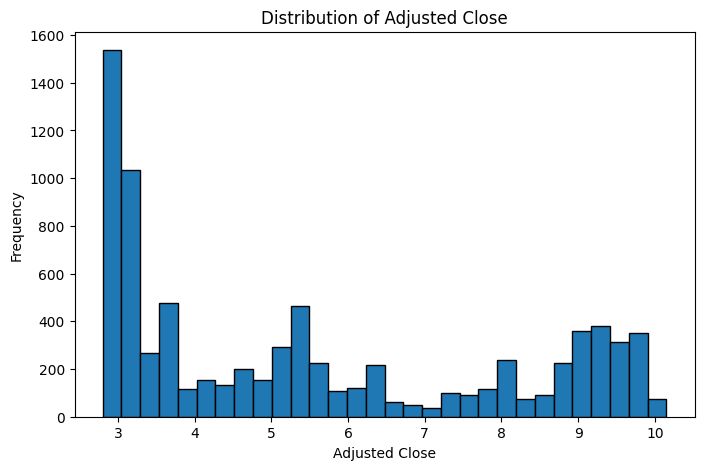

In [15]:
# Distribution of the target variable
plt.figure(figsize=(8, 5))
plt.hist(y, bins=30, edgecolor='black')
plt.xlabel('Adjusted Close')
plt.ylabel('Frequency')
plt.title('Distribution of Adjusted Close')
# save graph path
graphics_path = '/content/drive/MyDrive/UIUC/IE 498 - Machine Learning in Finance/week5/hw5_graphics/'
plt.savefig(graphics_path + 'target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

We also examine how Adj_Close changes over time.

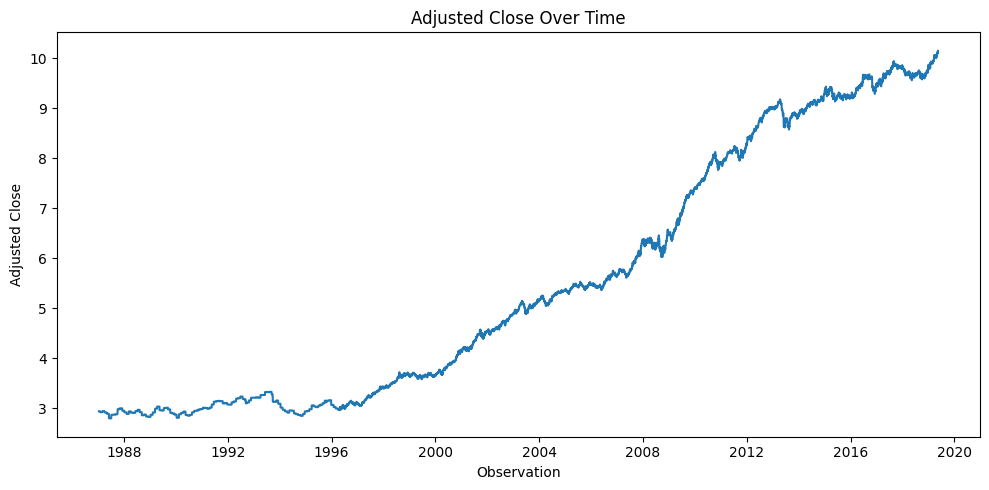

In [16]:
# Target versus observations
plt.figure(figsize=(10, 5))

plt.plot(data[target])

plt.xlabel("Observation")
plt.ylabel("Adjusted Close")
plt.title("Adjusted Close Over Time")
plt.tight_layout()

plt.savefig(graphics_path + "target_over_observations.png", dpi=300, bbox_inches="tight")

plt.show()

We next examine the distributions of all 30 attributes.

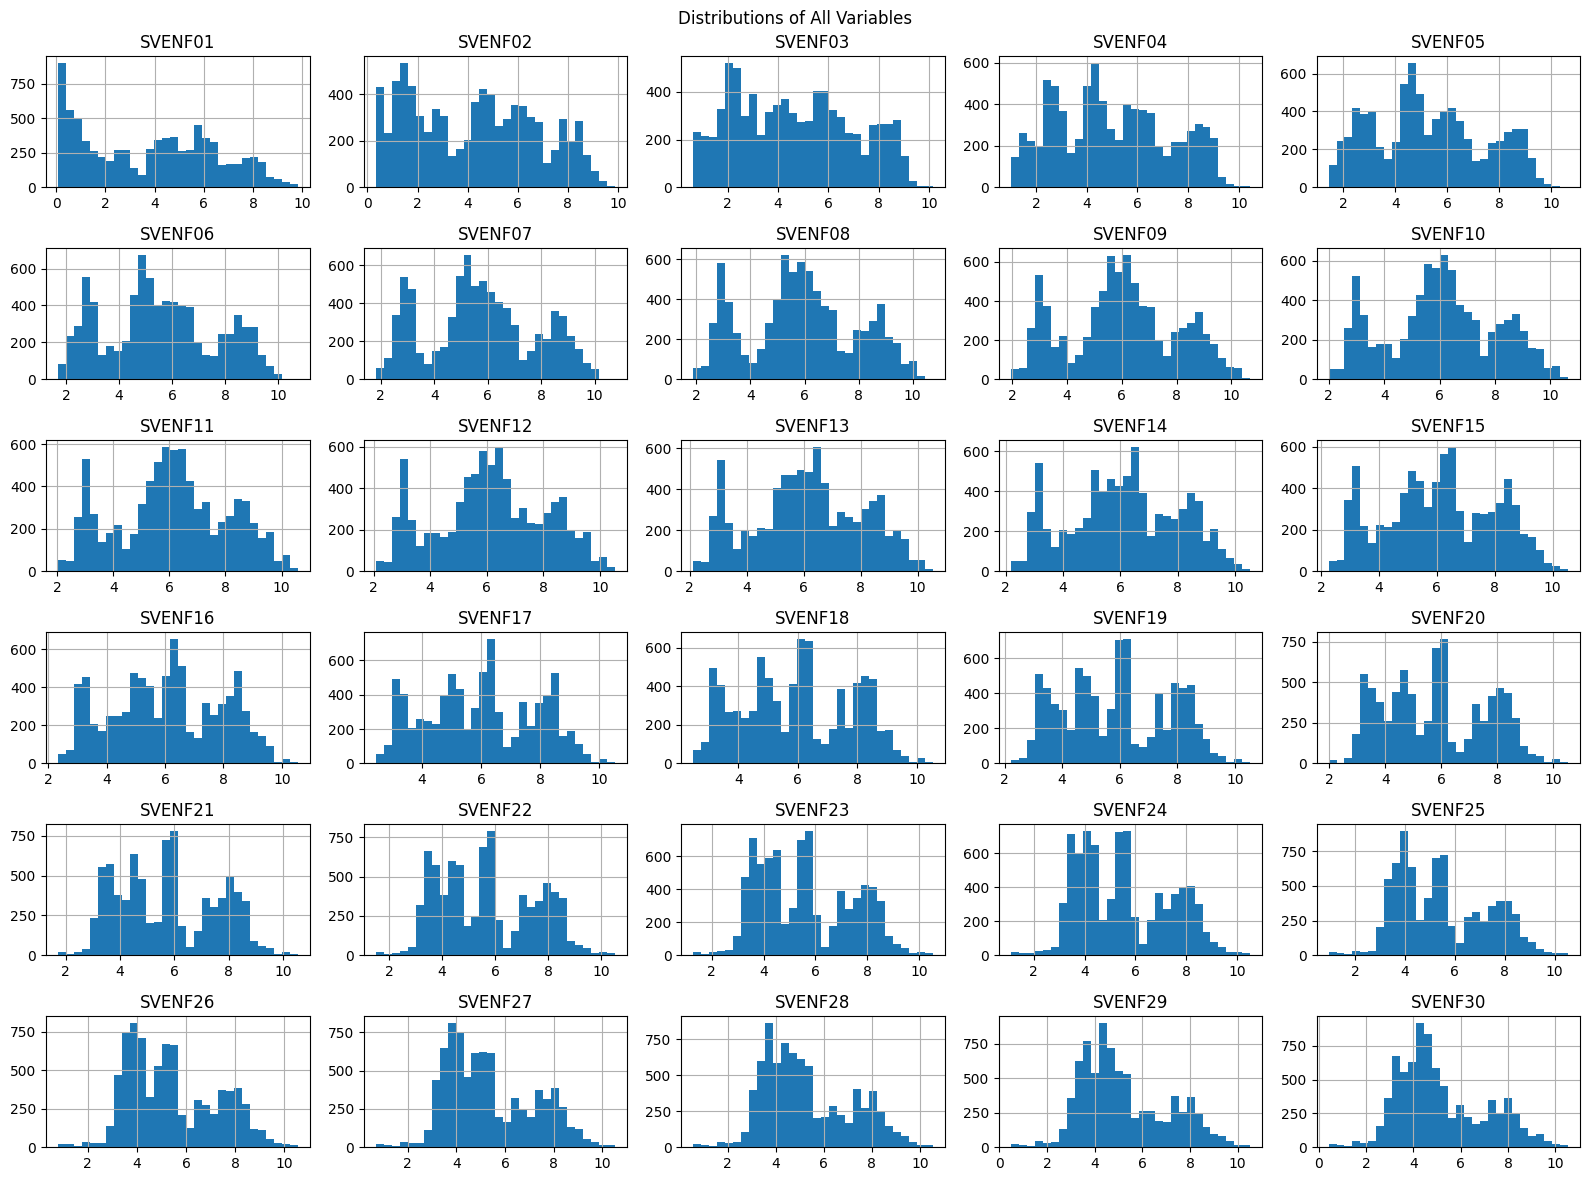

In [24]:
# Distributions of all variables
data.iloc[:,:-1].hist(figsize=(16, 12), bins=30)

plt.suptitle('Distributions of All Variables')
plt.tight_layout()
plt.savefig(graphics_path + 'Distributions_of_Variables.png', dpi=300, bbox_inches='tight')
plt.show()

We examine the pairwise correlations among all the variables.

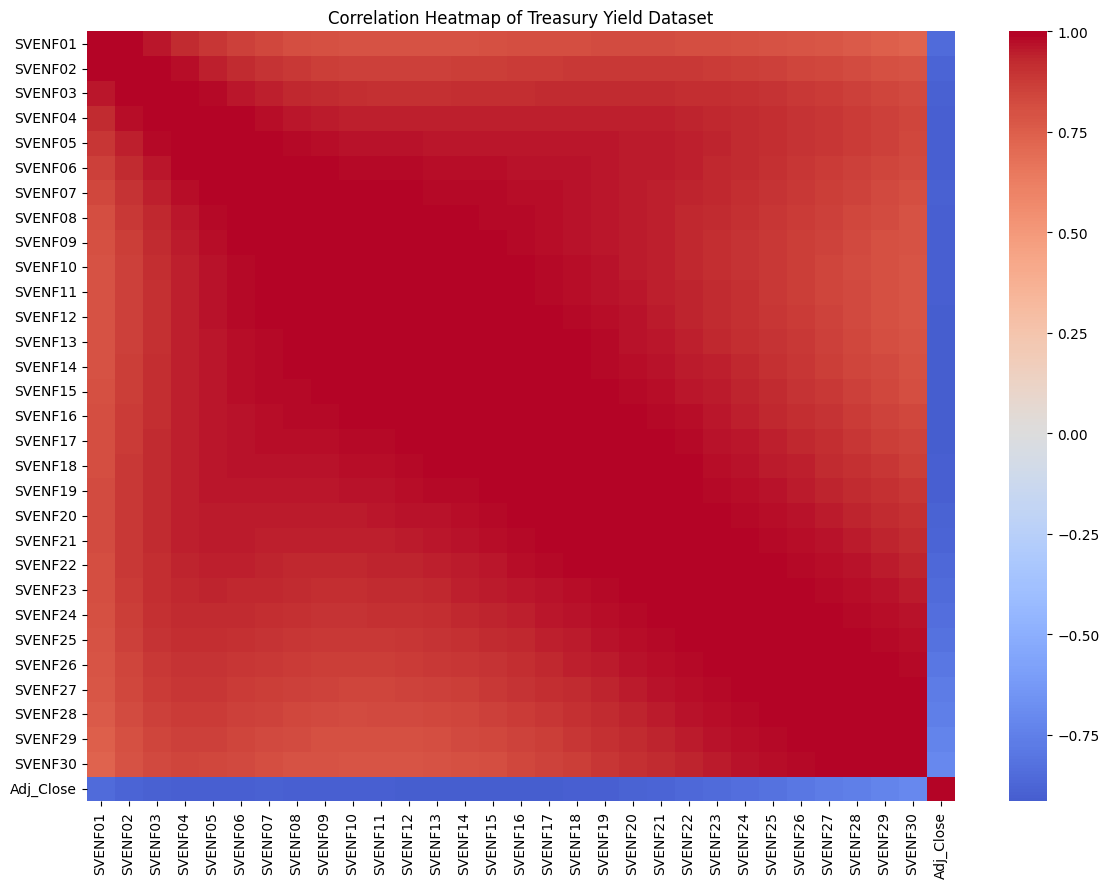

In [17]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Treasury Yield Dataset')
plt.savefig(graphics_path + 'correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

There is substantial correlation among the 30 attributes.

# 3. PCA

PCA is sensitive to the scale of the variables. Therefore, we standardize the predictor variables before applying PCA. Importantly, the scaler is fitted only on the training data and then applied to both the training and test sets.

In [25]:
from sklearn.preprocessing import StandardScaler

# Standardize features using only the training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# convert back to DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

We first fit PCA without specifying the number of components.

In [85]:
# PCA with all components
pca_all = PCA()

X_train_pca_all = pca_all.fit_transform(X_train_scaled)
X_test_pca_all = pca_all.transform(X_test_scaled)

explained_variance_ratio = pca_all.explained_variance_ratio_

explained_variance_table = pd.DataFrame({
    "Component": np.arange(1, len(explained_variance_ratio) + 1),
    "Explained Variance Ratio": explained_variance_ratio,
    "Cumulative Explained Variance":
        np.cumsum(explained_variance_ratio)
})

# print("\nExplained variance ratio for all components:")
# display(explained_variance_table)


We visualize the amount of variance explained by each principal component.

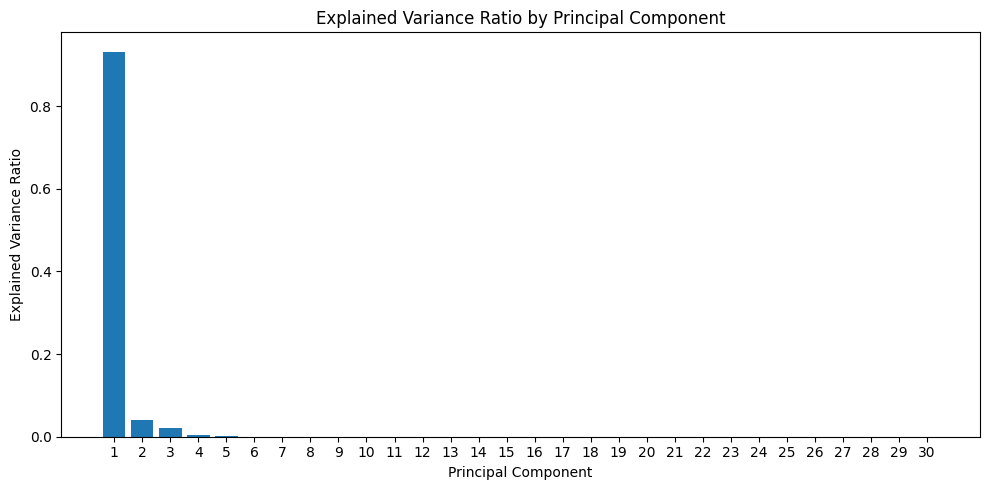

In [63]:
# Explained Variance Ratio by Principal Component
plt.figure(figsize=(10, 5))

plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio by Principal Component")
plt.xticks(range(1, len(explained_variance_ratio) + 1))

plt.tight_layout()
plt.savefig(graphics_path + "explained_variance_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

According to the assignment, we reduce the original 30 attributes to exactly three principal components. We therefore fit a second PCA model with n_components=3.

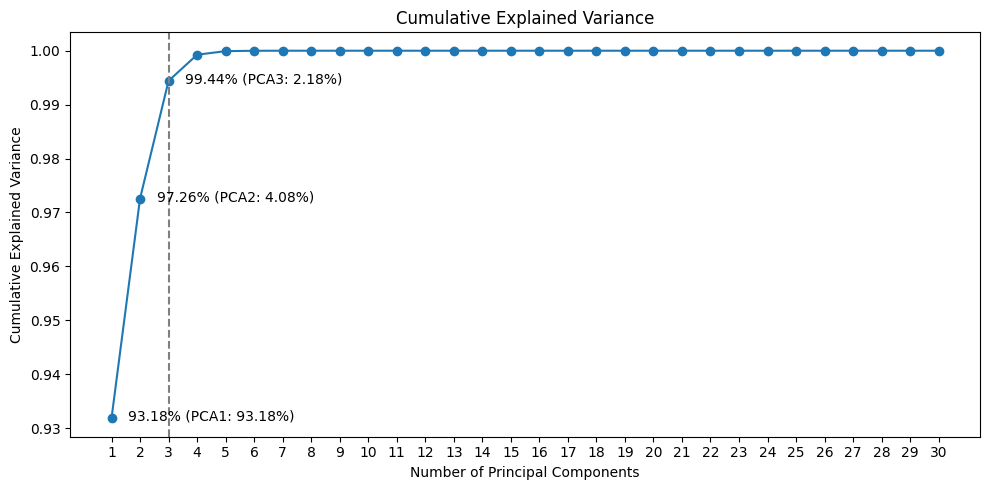

In [62]:
cumulative_variance = np.cumsum(explained_variance_ratio)
pca_3 = PCA(n_components=3)
X_train_pca = pca_3.fit_transform(X_train_scaled)
X_test_pca = pca_3.transform(X_test_scaled)
explained_3 = pca_3.explained_variance_ratio_
cumulative_pca_3 = np.sum(explained_3)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axvline(x=3, linestyle="--", color='grey')
# plt.axhline(y=cumulative_pca_3, linestyle="--")

for i in range(3):
    plt.annotate(f"{cumulative_variance[i] * 100:.2f}% (PCA{i+1}: {explained_3[i] * 100:.2f}%)",
        xy=(i + 1.3, cumulative_variance[i]-0.002),
        xytext=(6, 6), textcoords="offset points")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.tight_layout()
plt.savefig(graphics_path + "cumulative_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

The cumulative explained variance plot shows how much of the total variance is retained as additional principal components are included.

The three principal components explain 99.44% of the total variance in the original 30 attributes.

# 4. Model Fitting

#### Evaluation Metrics

We use R^2 and RMSE to evaluate the regression models.
* R^2: the proportion of variation in the response explained by the model
* RMSE: the typical magnitude of prediction errors.

Higher R^2 and lower RMSE indicate better predictive performance.

In [64]:
# Helper function
# prediction, R2, RMSE
def calculate_metrics(model, X_train, X_test, y_train, y_test):

    # Training prediction
    y_train_pred = model.predict(X_train)

    # Test prediction
    y_test_pred = model.predict(X_test)

    # R2
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # RMSE
    train_rmse = np.sqrt( mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    return {"Train R2": train_r2,
          "Test R2": test_r2,
          "Train RMSE": train_rmse,
          "Test RMSE": test_rmse}

## 4.1 Linear Regression

### (Linear Regression - Baseline)
We first fit a Linear Regression model using all 30 original attributes. This provides the baseline linear model against which the PCA-based model can be compared.

In [70]:
# Linear Regression
start_time = time.perf_counter()
linear_baseline = LinearRegression()
linear_baseline.fit(X_train_scaled, y_train)
linear_baseline_time = (time.perf_counter() - start_time)

linear_baseline_results = calculate_metrics(linear_baseline, X_train_scaled, X_test_scaled, y_train, y_test)

print("\nTraining time:")
print(f"{linear_baseline_time:.6f} seconds")

print("\nResults:")
for key, value in linear_baseline_results.items():
    print(f"{key}: {value:.6f}")


Training time:
0.030079 seconds

Results:
Train R2: 0.902273
Test R2: 0.904131
Train RMSE: 0.776653
Test RMSE: 0.782370


### (Linear Regression - PCA)
We next fit Linear Regression using only the three principal components. This experiment evaluates how reducing the feature space from 30 attributes to three components affects predictive performance.

In [67]:
start_time = time.perf_counter()
linear_pca = LinearRegression()
linear_pca.fit(X_train_pca, y_train)
linear_pca_time = (time.perf_counter() - start_time)

linear_pca_results = calculate_metrics(linear_pca, X_train_pca, X_test_pca, y_train, y_test)

print("\nTraining time:")
print(f"{linear_pca_time:.6f} seconds")

print("\nResults:")
for key, value in linear_pca_results.items():
    print(f"{key}: {value:.6f}")


Training time:
0.005784 seconds

Results:
Train R2: 0.867218
Test R2: 0.866242
Train RMSE: 0.905294
Test RMSE: 0.924131


## 4.2 SVR

### (SVM - Baseline)

We now fit an SVR using all 30 standardized attributes. Standardization is important for SVR because the model is sensitive to the relative scale of the input variables.

In [68]:
start_time = time.perf_counter()
svr_baseline = SVR(kernel="rbf")
svr_baseline.fit(X_train_scaled, y_train)
svr_baseline_time = (time.perf_counter() - start_time)

svr_baseline_results = calculate_metrics(svr_baseline, X_train_scaled, X_test_scaled, y_train, y_test)

print("\nTraining time:")
print(f"{svr_baseline_time:.6f} seconds")

print("\nResults:")
for key, value in svr_baseline_results.items():
    print(f"{key}: {value:.6f}")



Training time:
6.308690 seconds

Results:
Train R2: 0.988651
Test R2: 0.989128
Train RMSE: 0.264669
Test RMSE: 0.263472


### (SVR - PCA)

we fit the SVR using only the three principal components. This allows us to examine whether dimensionality reduction can reduce computational cost while maintaining predictive performance.

In [69]:

start_time = time.perf_counter()
svr_pca = SVR(kernel="rbf")
svr_pca.fit(X_train_pca, y_train)
svr_pca_time = (time.perf_counter() - start_time)

svr_pca_results = calculate_metrics(svr_pca, X_train_pca, X_test_pca, y_train, y_test)

print("\nTraining time:")
print(f"{svr_pca_time:.6f} seconds")

print("\nResults:")
for key, value in svr_pca_results.items():
    print(f"{key}: {value:.6f}")




Training time:
2.762950 seconds

Results:
Train R2: 0.977966
Test R2: 0.977669
Train RMSE: 0.368779
Test RMSE: 0.377595


## 5. Model Comparison

We now combine the results from all four experiments.

In [75]:
# Results Table

results = pd.DataFrame({

    "Linear Regression - Baseline": [
        linear_baseline_results["Train R2"],
        linear_baseline_results["Test R2"],
        linear_baseline_results["Train RMSE"],
        linear_baseline_results["Test RMSE"],
        linear_baseline_time
    ],

    "SVR - Baseline": [
        svr_baseline_results["Train R2"],
        svr_baseline_results["Test R2"],
        svr_baseline_results["Train RMSE"],
        svr_baseline_results["Test RMSE"],
        svr_baseline_time
    ],

    "Linear Regression - PCA": [
        linear_pca_results["Train R2"],
        linear_pca_results["Test R2"],
        linear_pca_results["Train RMSE"],
        linear_pca_results["Test RMSE"],
        linear_pca_time
    ],

    "SVR - PCA": [
        svr_pca_results["Train R2"],
        svr_pca_results["Test R2"],
        svr_pca_results["Train RMSE"],
        svr_pca_results["Test RMSE"],
        svr_pca_time
    ]

}, index=[
    "Train R2",
    "Test R2",
    "Train RMSE",
    "Test RMSE",
    "Training Time (seconds)"
])


print("Final Results:")
display(results)

Final Results:


,Linear Regression - Baseline,SVR - Baseline,Linear Regression - PCA,SVR - PCA
Train R2,0.902273,0.988651,0.867218,0.977966
Test R2,0.904131,0.989128,0.866242,0.977669
Train RMSE,0.776653,0.264669,0.905294,0.368779
Test RMSE,0.782370,0.263472,0.924131,0.377595
Training Time (seconds),0.030079,6.308690,0.005784,2.762950


In [74]:
print("Training times:\n")
print(f"Linear Regression - Baseline: {linear_baseline_time:.6f} sec")
print(f"Linear Regression - PCA: {linear_pca_time:.6f} sec")
print(f"SVR - Baseline: {svr_baseline_time:.6f} sec")
print(f"SVR - PCA: {svr_pca_time:.6f} sec")


Training times:

Linear Regression - Baseline: 0.030079 sec
Linear Regression - PCA: 0.005784 sec
SVR - Baseline: 6.308690 sec
SVR - PCA: 2.762950 sec


We see that PCA effectively reduces the training time for both models.

### Actual vs. Predicted Adjusted Close for All Models

To further compare the four models, we plot the predicted values against the actual Adj_Close values for the test set.

* x-axis: actual Adj_Close
* y-axis: predicted Adj_Close
* Each dot = one observation from test observation
* The dashed 45° line is perfect prediction

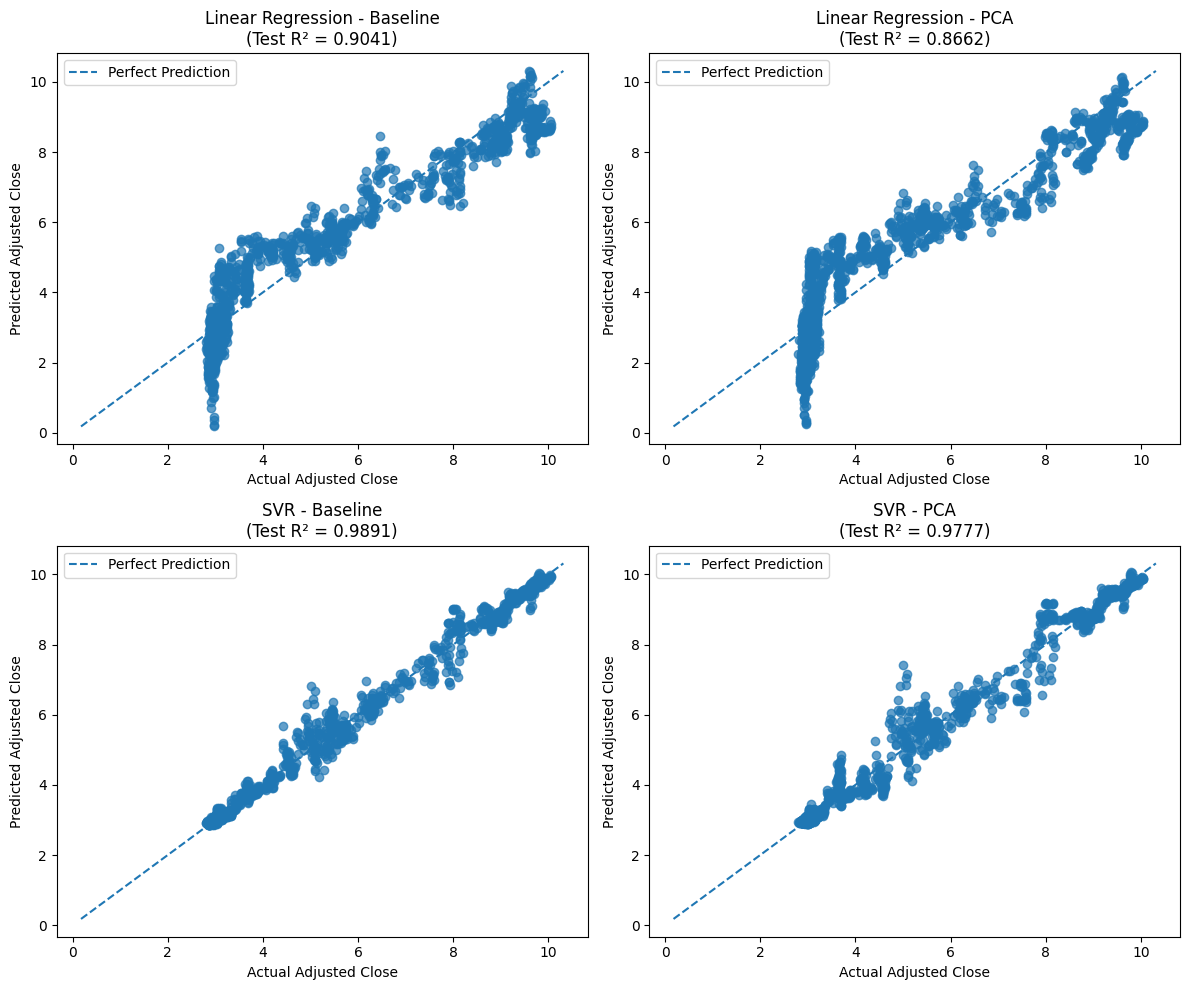

In [84]:
y_test_pred_linear_baseline = linear_baseline.predict(X_test_scaled)
y_test_pred_linear_pca = linear_pca.predict(X_test_pca)
y_test_pred_svr_baseline = svr_baseline.predict(X_test_scaled)
y_test_pred_svr_pca = svr_pca.predict(X_test_pca)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

min_value = min(
    y_test.min(),
    y_test_pred_linear_baseline.min(),
    y_test_pred_linear_pca.min(),
    y_test_pred_svr_baseline.min(),
    y_test_pred_svr_pca.min()
)
max_value = max(
    y_test.max(),
    y_test_pred_linear_baseline.max(),
    y_test_pred_linear_pca.max(),
    y_test_pred_svr_baseline.max(),
    y_test_pred_svr_pca.max()
)

axes[0, 0].scatter(y_test, y_test_pred_linear_baseline, alpha=0.7)
axes[0, 0].plot([min_value, max_value], [min_value, max_value], linestyle="--", label="Perfect Prediction")
axes[0, 0].set_xlabel("Actual Adjusted Close")
axes[0, 0].set_ylabel("Predicted Adjusted Close")
axes[0, 0].set_title(f"Linear Regression - Baseline\n(Test R² = {linear_baseline_results['Test R2']:.4f})")
axes[0, 0].legend()

axes[0, 1].scatter(y_test, y_test_pred_linear_pca, alpha=0.7)
axes[0, 1].plot([min_value, max_value], [min_value, max_value], linestyle="--", label="Perfect Prediction")
axes[0, 1].set_xlabel("Actual Adjusted Close")
axes[0, 1].set_ylabel("Predicted Adjusted Close")
axes[0, 1].set_title(f"Linear Regression - PCA\n(Test R² = {linear_pca_results['Test R2']:.4f})")
axes[0, 1].legend()

axes[1, 0].scatter(y_test, y_test_pred_svr_baseline, alpha=0.7)
axes[1, 0].plot([min_value, max_value], [min_value, max_value], linestyle="--", label="Perfect Prediction")
axes[1, 0].set_xlabel("Actual Adjusted Close")
axes[1, 0].set_ylabel("Predicted Adjusted Close")
axes[1, 0].set_title(f"SVR - Baseline\n(Test R² = {svr_baseline_results['Test R2']:.4f})")
axes[1, 0].legend()

axes[1, 1].scatter(y_test, y_test_pred_svr_pca, alpha=0.7)
axes[1, 1].plot([min_value, max_value], [min_value, max_value], linestyle="--", label="Perfect Prediction")
axes[1, 1].set_xlabel("Actual Adjusted Close")
axes[1, 1].set_ylabel("Predicted Adjusted Close")
axes[1, 1].set_title(f"SVR - PCA\n(Test R² = {svr_pca_results['Test R2']:.4f})")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(graphics_path + "actual_vs_predicted_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

In [86]:
print("My name is Rong Gan")
print("My NetID is: ronggan2")
print("I hereby certify that I have read the University policy on Academic Integrity and that I am not in violation.")

My name is Rong Gan
My NetID is: ronggan2
I hereby certify that I have read the University policy on Academic Integrity and that I am not in violation.
